# Notebook 03 — Topic Modeling & Thematic Analysis

**Project:** Thematic Evolution of French Electoral Manifestos (1973–1993)  
**Course:** Machine Learning for NLP — ENSAE Paris, 2025–2026  
**Author:** Gabriel Orsatti

---

## Motivation & Approach

Topic modeling is a family of unsupervised methods for discovering latent thematic structure in document collections. As Blei (2012) defines it, a topic is a *distribution over a fixed vocabulary*, and each document exhibits multiple topics in different proportions. The course (*Lecture 6*) introduces two main approaches:

- **LDA** (Blei et al., 2003): a *probabilistic generative model* where each document is a mixture of topics drawn from Dirichlet priors, and each topic is a distribution over words. The generative process (Lecture 6, slide 8): *(1) choose a distribution over topics; (2) for each word, choose a topic, then choose a word from that topic.*
- **NMF** (Lee & Seung, 1999): a *linear algebra factorization* $V \approx W \times H$ where $W$ is the document-topic matrix and $H$ the topic-word matrix. Unlike LDA, NMF has *"no probabilistic assumptions"* (Lecture 6, comparison table) and operates on TF-IDF rather than raw counts.

We add a third paradigm — **BERTopic** (Grootendorst, 2022) — which leverages pre-trained Transformer embeddings (*Lecture 7*) to capture semantic similarity beyond bag-of-words co-occurrence.

**Key design choices:**
1. Each model is trained at **its own optimal $k$**, selected via $C_v$ coherence — *"the metric most correlated with human ratings"* (Röder et al., 2015; Lecture 6, slides 19–22)
2. The **primary model for cross-analysis** is selected by combining Cv with **distribution balance** — a degenerate model (80%+ of docs in one topic) is rejected even if its Cv is high
3. A two-stage approach: **baseline LDA on full vocabulary** (diagnostic) → **improved models on clean vocabulary** (partisan stopwords removed)

**Checkpoint system:** Expensive computations cached in `../data/checkpoints/`.

---

## Table of Contents

1. Environment & Data Preparation
2. Lemmatization with spaCy
3. Baseline LDA (full vocabulary) — diagnostic
4. Improved Models: optimal $k$ selection, final LDA & NMF
5. BERTopic (embedding-based)
6. Quantitative Model Comparison
7. Cross-Analysis: Topics × Metadata
8. Save & Summary

---
## 1. Environment & Data Preparation
### 1.1 Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re, string, os, pickle, json, time, ast
from collections import Counter
import urllib.request
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE

CHECKPOINT_DIR = Path("../data/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_pickle("../data/df_explore.pkl")
print(f"DataFrame loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Years: {sorted(df['year'].unique())}")

DataFrame loaded: 21,697 rows × 52 columns
Years: ['1973', '1978', '1981', '1988', '1993']


### 1.2 Visual style

In [12]:
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)
for name, url in {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'
PARTY_COLORS = {'PCF': '#D4626E', 'PS': '#E8919A', 'Radicaux': '#F0B87E',
    'Ecologistes': '#8CBF8C', 'UDF': '#7EADD4', 'RPR': '#5B8DB8',
    'FN': '#2E4A62', 'Non mentionné': '#C4BFB6', 'Autre': '#A89F96'}
YEAR_COLORS = {
    '1973': '#C9A891', 
    '1978': '#8BA89D',  
    '1981': '#D4626E',
    '1988': '#7EADD4',
    '1993': '#5B8DB8'
}
BG_COLOR = '#FAF7F2'; TEXT_COLOR = '#2C2824'; GRID_COLOR = '#E8E4DD'
plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN']
print("Style configured ✓")

Style configured ✓


### 1.3 Text preparation & language filtering

We filter documents shorter than 100 characters and remove German-language manifestos from Alsace-Moselle (bilingual electoral tradition). These would create a spurious "German language" topic unrelated to French political themes.

In [13]:
if 'text_clean' not in df.columns:
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower().replace('\n', ' ').replace('\r', ' ')
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        return re.sub(r'\s+', ' ', text).strip()
    df['text_clean'] = df['text'].apply(clean_text)

df_topic = df[df['text_clean'].str.len() > 100].copy()

def is_french(text):
    if not isinstance(text, str): return False
    german = ['die', 'der', 'und', 'für', 'den', 'sie', 'das', 'ist', 'von']
    words = text.lower().split()
    if len(words) == 0: return False
    return sum(1 for w in words if w in german) / len(words) < 0.05

mask_fr = df_topic['text_clean'].apply(is_french)
df_topic = df_topic[mask_fr].copy()
print(f"Documents retained: {len(df_topic):,} (filtered {(~mask_fr).sum()} German-language docs)")

Documents retained: 21,139 (filtered 556 German-language docs)


---
## 2. Lemmatization with spaCy

The course recommends the pipeline (*Lecture 6, slide 13*): `Lemmatization + Stop Words + CountVectorizer + LDA`. Lemmatization reduces inflected forms to their *"canonical form, dictionary form, or citation form"* (*Lecture 4*), unlike stemming which *"chops off the ends of words"* and may produce non-words.

We use spaCy's `fr_core_news_md`, a French model trained on newspaper text — well-suited to our political corpus. The course notes (*Lecture 4, slide 18*) that *"in practice, stemming is a crude and incorrect approximation of lemmatization"* — we therefore opt for the more accurate approach.

In [14]:
#pip install spacy

In [15]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "spacy", "download", "fr_core_news_md"], check=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 12.1 MB/s  0:00:03m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


CompletedProcess(args=['/opt/python/bin/python', '-m', 'spacy', 'download', 'fr_core_news_md'], returncode=0)

In [16]:
CHECKPOINT_LEMMA = CHECKPOINT_DIR / "lemmatized_tokens.json"

if CHECKPOINT_LEMMA.exists():
    with open(CHECKPOINT_LEMMA, 'r') as f:
        token_lists = json.load(f)
    
    if len(token_lists) == len(df_topic):
        df_topic['tokens_lemma'] = token_lists
        print(f"✓ Lemmatized tokens loaded from cache ({len(token_lists):,} docs)")
    else:
        print(f"⚠ Cache size mismatch: {len(token_lists):,} cached vs {len(df_topic):,} docs in corpus.")
        print(f"  Cache outdated (old corpus without 1973/1978) → deleting and re-lemmatizing...")
        CHECKPOINT_LEMMA.unlink()
        token_lists = None  # force the else branch below

if not CHECKPOINT_LEMMA.exists():
    import spacy
    nlp_spacy = spacy.load("fr_core_news_md", disable=["ner", "parser"])
    STOPWORDS_ALL = set(nlp_spacy.Defaults.stop_words)
    STOPWORDS_ALL.update({
        'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
        'encore', 'tant', 'rien', 'autre', 'même', 'non', 'oui', 'comme',
        'politique', 'france', 'français', 'française', 'république',
        'candidat', 'élection', 'vote', 'voter', 'circonscription',
        'député', 'suppléant', 'conseiller', 'maire', 'président',
        'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller',
        'janvier', 'février', 'mars', 'avril', 'mai', 'juin',
        'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
    })
    print(f"Lemmatizing {len(df_topic):,} documents...")
    t0 = time.time()
    token_lists = []
    for i, doc in enumerate(nlp_spacy.pipe(df_topic['text_clean'], batch_size=500, n_process=1)):
        tokens = [token.lemma_.lower() for token in doc
                  if not token.is_stop and token.lemma_.lower() not in STOPWORDS_ALL
                  and len(token.lemma_) > 2 and token.is_alpha]
        token_lists.append(tokens)
        if (i + 1) % 2000 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(df_topic) - i - 1)
            print(f"  {i+1:,}/{len(df_topic):,} | {elapsed/60:.1f}min | ETA: {eta/60:.1f}min")
    df_topic['tokens_lemma'] = token_lists
    with open(CHECKPOINT_LEMMA, 'w') as f:
        json.dump(token_lists, f, ensure_ascii=False)
    print(f"✓ Done ({time.time()-t0:.0f}s)")

print(f"Sample: {token_lists[0][:12]}")

Lemmatizing 21,139 documents...
  2,000/21,139 | 2.4min | ETA: 22.7min
  4,000/21,139 | 4.2min | ETA: 18.0min
  6,000/21,139 | 6.1min | ETA: 15.3min
  8,000/21,139 | 7.5min | ETA: 12.3min
  10,000/21,139 | 9.2min | ETA: 10.3min
  12,000/21,139 | 11.3min | ETA: 8.6min
  14,000/21,139 | 14.1min | ETA: 7.2min
  16,000/21,139 | 17.5min | ETA: 5.6min
  18,000/21,139 | 20.4min | ETA: 3.6min
  20,000/21,139 | 21.7min | ETA: 1.2min
✓ Done (1349s)
Sample: ['législatif', 'candidature', 'lutte', 'ouvrier', 'lutte', 'ouvrier', 'révolutionnaire', 'révolutionnaire', 'entendre', 'connaître', 'mal', 'radio']


---
## 3. Baseline LDA (Full Vocabulary, k=12)

Before any vocabulary cleaning, we train a standard LDA to observe what the model captures "out of the box". This serves as a **diagnostic step** — we expect the model to latch onto the most statistically distinctive word groups, which in a political corpus means party-specific jargon.

### 3.1 Utility function

In [17]:
def get_topic_words(model, feature_names, n_words=15):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        topics[idx] = [feature_names[i] for i in top_indices]
    return topics

### 3.2 Baseline model

Following the course pipeline (*Lecture 6, slide 11*): `CountVectorizer + Stop Words + LatentDirichletAllocation`.

In [18]:
STOPWORDS_BASE = [
    'le','la','les','de','des','du','un','une','et','en','à','au','aux','ce','ces',
    'que','qui','dans','pour','par','sur','avec','son','ses','sa','se','ne','pas',
    'nous','vous','ils','est','sont','ont','été','être','avoir','fait','faire','plus',
    'tout','tous','toute','toutes','mais','ou','où','si','leur','leurs','elle','elles',
    'il','je','me','mon','ma','mes','notre','nos','votre','vos','même','aussi','bien',
    'peut','cette','cet','dont','comme','sans','entre','très','après','avant','autres',
    'autre','encore','quand','car','donc','sera','non','oui','puis','ici','là','ya',
    'ça','cela','ceci','on','ny','na','ni','peu','chaque','sous','depuis','eux','lui',
    'celle','ceux','celui','quelques','tant','ainsi','vers','chez','contre','dès','trop',
    'lors','déjà','soit','afin','tel','telle','cest','quil','quils','dune','dun','jai',
    'lassemblée','nationale','national','suis','nest','naura','quon',
    'circonscription','candidat','candidate','élections','législatives',
    'république','française','france','département','juin','mars',
    'tour','scrutin','vote','voter','électeurs','électeur',
    'profession','foi','premier','première','second','seconde',
    'nom','prénom','année','années','ans','deux','trois',
    'faut','doit','peuvent','doivent','falloir','pouvoir',
    'devoir','aller','dire','voir','vouloir','savoir',
]
count_vectorizer = CountVectorizer(max_features=5000, min_df=10, max_df=0.7,
    stop_words=STOPWORDS_BASE, ngram_range=(1, 2))
count_matrix = count_vectorizer.fit_transform(df_topic['text_clean'])
feature_names = count_vectorizer.get_feature_names_out()
N_TOPICS_BASELINE = 12
lda_baseline = LatentDirichletAllocation(n_components=N_TOPICS_BASELINE, max_iter=30,
    learning_method='online', random_state=42, n_jobs=-1)
lda_baseline_topics = lda_baseline.fit_transform(count_matrix)
print(f"Baseline LDA: {count_matrix.shape}, k={N_TOPICS_BASELINE}")
print(f"\n=== Baseline Topics ===\n")
for tid, words in get_topic_words(lda_baseline, feature_names, 10).items():
    print(f"Topic {tid:2d}: {', '.join(words)}")

Baseline LDA: (21139, 5000), k=12

=== Baseline Topics ===

Topic  0: travailleurs, alors, patrons, payer, entreprises, barre, maintenir, salaires, hommes politiques, chômage
Topic  1: majorité, député, conseiller, maire, président, confiance, général, socialiste, suppléant, candidats
Topic  2: droite, gauche, parti, mitterrand, députés, candidats, marchais, politique, gouvernement, communistes
Topic  3: travailleuses, suppléant, travailleuses travailleurs, lutte, travailleurs, ouvriere, lutte ouvriere, ouvrière, laguiller, candidats
Topic  4: politique, français, sociale, travail, création, liberté, loi, famille, programme, charges
Topic  5: gauche, communiste, parti, programme, commun, politique, programme commun, parti communiste, changement, socialiste
Topic  6: travailleurs, socialisme, travail, femmes, société, gauche, droit, lautogestion, psu, ps
Topic  7: politique, vie, pays, travail, société, développement, sociale, économique, région, hommes
Topic  8: nature, nouveaux, anima

**Diagnosis:** The baseline LDA confirms our hypothesis — it captures **partisan identities** rather than policy themes. The FN's distinctive vocabulary (immigration, insécurité, front national), the PCF's discourse (travailleurs, lutte, ouvrier), and the ecology movement's jargon (nature, animaux, écologie) each form separate topics. Only 1–2 topics out of 12 represent genuine cross-partisan policy content.

This is expected: as the course's LDA generative model shows (*Lecture 6, slide 8*), LDA finds the word distributions that best explain the observed data. When party-specific vocabulary is highly distinctive, it dominates the latent structure.

**→ Solution:** Remove partisan vocabulary to force the model to discover *substantive* policy themes.

---
## 4. Improved Models (Clean Vocabulary, Optimal k)

### 4.1 Partisan stopwords

We extend the stopword list with party names, leader names, slogans, and OCR artifacts. This is analogous to the course's recommendation (*Lecture 2, slide 9*): *"Remove non-informative words with a custom word list."*

In [19]:
STOPWORDS_PARTISAN = STOPWORDS_BASE + [
    'front','rpr','udf','pcf','rpf','fnr',
    'communiste','communistes','socialiste','socialistes',
    'gaulliste','gaullistes','écologiste','écologistes',
    'ecologiste','ecologistes','verts','vert',
    'radical','radicaux','centriste','centristes',
    'lutte','ouvrière','laguiller','arlette',
    'mitterrand','chirac','giscard','marchais','barre','lepen','pen',
    'parti','partis','mouvement','rassemblement','union',
    'coalition','alliance','entente','liste',
    'député','députés','suppléant','suppléante',
    'conseiller','conseillère','maire','président',
    'sénateur','assemblée','sénat','parlement',
    'candidat','candidate','candidats','candidates',
    'mandat','mandats','élu','élue','élus',
    'votez','voter','voix','bulletin','urne',
    'confiance','soutien','soutenir','appel',
    'madame','monsieur','mademoiselle','chers','concitoyens',
    'électeurs','électrices','mengage','engage','promets',
    'vive','force','davenir','avenir','convictions','populaire','ensemble',
    'gauche','droite','centre',
    'lécologie','lentente','lhomme','lunion',
    'quil','quils','quon','quelles',
    'naturelle','loi naturelle','connaissance','transcendantale','méditation',
]
print(f"Partisan stopwords: {len(STOPWORDS_PARTISAN)} terms")

Partisan stopwords: 278 terms


### 4.2 Gensim corpus

We use **gensim** for coherence evaluation — the course identifies it as *"specialized in topic modelling"* (*Lecture 6, slide 24*). Gensim provides native access to $C_v$, $C_{UMass}$, $C_{UCI}$, and $C_{NPMI}$ metrics.

In [21]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 695.3 kB/s  0:00:41m0:00:0100:02
Note: you may need to restart the kernel to use updated packages.


In [23]:
from gensim import corpora
from gensim.models import CoherenceModel, LdaMulticore

gensim_dictionary = corpora.Dictionary(token_lists)
gensim_dictionary.filter_extremes(no_below=5, no_above=0.6)
gensim_corpus = [gensim_dictionary.doc2bow(tokens) for tokens in token_lists]
print(f"Gensim dictionary: {len(gensim_dictionary)} terms | Corpus: {len(gensim_corpus)} docs")

Gensim dictionary: 29505 terms | Corpus: 21139 docs


### 4.3 Optimal $k$ selection (grid search)

As the course emphasizes (*Lecture 6, slide 22*):
> *"The number of topics is a meta-parameter that needs to be optimised."*

We evaluate $C_v$ coherence — *"a metric 'discovered' through systematic experiments to find the correlation between coherence metrics and human ratings"* (Röder et al., 2015; Lecture 6, slide 21). The $C_v$ pipeline combines NPMI vectors with cosine similarity across sliding windows.

**Critical design choice:** Each model gets **its own optimal $k$**. LDA (probabilistic, with Dirichlet priors that regularize topic distributions) and NMF (algebraic, no regularization) have different statistical properties and may require different granularity. Forcing both to the same $k$ would disadvantage one model.

**NMF sensitivity note:** NMF is highly sensitive to vocabulary size. We use `min_df=15` and `max_features=3000` — using looser settings (e.g., `min_df=5`) allows rare words that cause NMF to isolate hyper-specific micro-clusters rather than cross-partisan themes.

In [24]:
CHECKPOINT_GRID = CHECKPOINT_DIR / "grid_search_v8.json"

if CHECKPOINT_GRID.exists():
    with open(CHECKPOINT_GRID, 'r') as f:
        grid = json.load(f)
    range_topics = grid['range_topics']
    lda_cv = grid['lda_cv']; lda_umass = grid['lda_umass']
    nmf_cv = grid['nmf_cv']; nmf_umass = grid['nmf_umass']
    nmf_recon = grid['nmf_recon']
    print(f"✓ Grid search loaded from cache")
else:
    range_topics = [5, 7, 9, 11, 13, 15]
    lda_cv, lda_umass = [], []
    nmf_cv, nmf_umass, nmf_recon = [], [], []

    tfidf_vec_grid = TfidfVectorizer(max_features=3000, min_df=15, max_df=0.6,
        stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2))
    tfidf_matrix_grid = tfidf_vec_grid.fit_transform(df_topic['text_clean'])
    tfidf_names_grid = tfidf_vec_grid.get_feature_names_out()

    print("=" * 70)
    print(f"Grid Search — LDA (gensim) + NMF (sklearn)")
    print(f"TF-IDF: {tfidf_matrix_grid.shape}")
    print("=" * 70)
    t0 = time.time()

    for step, k in enumerate(range_topics):
        t_step = time.time()
        lda_g = LdaMulticore(gensim_corpus, num_topics=k, id2word=gensim_dictionary,
                              passes=10, workers=2, random_state=42)
        cm1 = CoherenceModel(model=lda_g, texts=token_lists, dictionary=gensim_dictionary, coherence='c_v')
        cm2 = CoherenceModel(model=lda_g, texts=token_lists, dictionary=gensim_dictionary, coherence='u_mass')
        lda_cv.append(cm1.get_coherence()); lda_umass.append(cm2.get_coherence())

        nmf_k = NMF(n_components=k, random_state=42, max_iter=300, init='random')
        nmf_k.fit(tfidf_matrix_grid)
        nmf_recon.append(nmf_k.reconstruction_err_)
        nmf_words = [[tfidf_names_grid[j] for j in t.argsort()[-10:][::-1]] for t in nmf_k.components_]
        cm3 = CoherenceModel(topics=nmf_words, texts=token_lists, dictionary=gensim_dictionary, coherence='c_v')
        cm4 = CoherenceModel(topics=nmf_words, texts=token_lists, dictionary=gensim_dictionary, coherence='u_mass')
        nmf_cv.append(cm3.get_coherence()); nmf_umass.append(cm4.get_coherence())

        elapsed = time.time() - t0
        eta = elapsed / (step+1) * (len(range_topics) - step - 1)
        print(f"  k={k:2d} | LDA Cv={lda_cv[-1]:.4f} | NMF Cv={nmf_cv[-1]:.4f} | {time.time()-t_step:.0f}s | ETA: {eta/60:.1f}min")

    with open(CHECKPOINT_GRID, 'w') as f:
        json.dump({'range_topics': range_topics, 'lda_cv': lda_cv, 'lda_umass': lda_umass,
                   'nmf_cv': nmf_cv, 'nmf_umass': nmf_umass, 'nmf_recon': nmf_recon}, f)
    print(f"\n✓ Saved ({time.time()-t0:.0f}s)")

✓ Grid search loaded from cache


### 4.4 Evaluation plots & independent $k$ selection

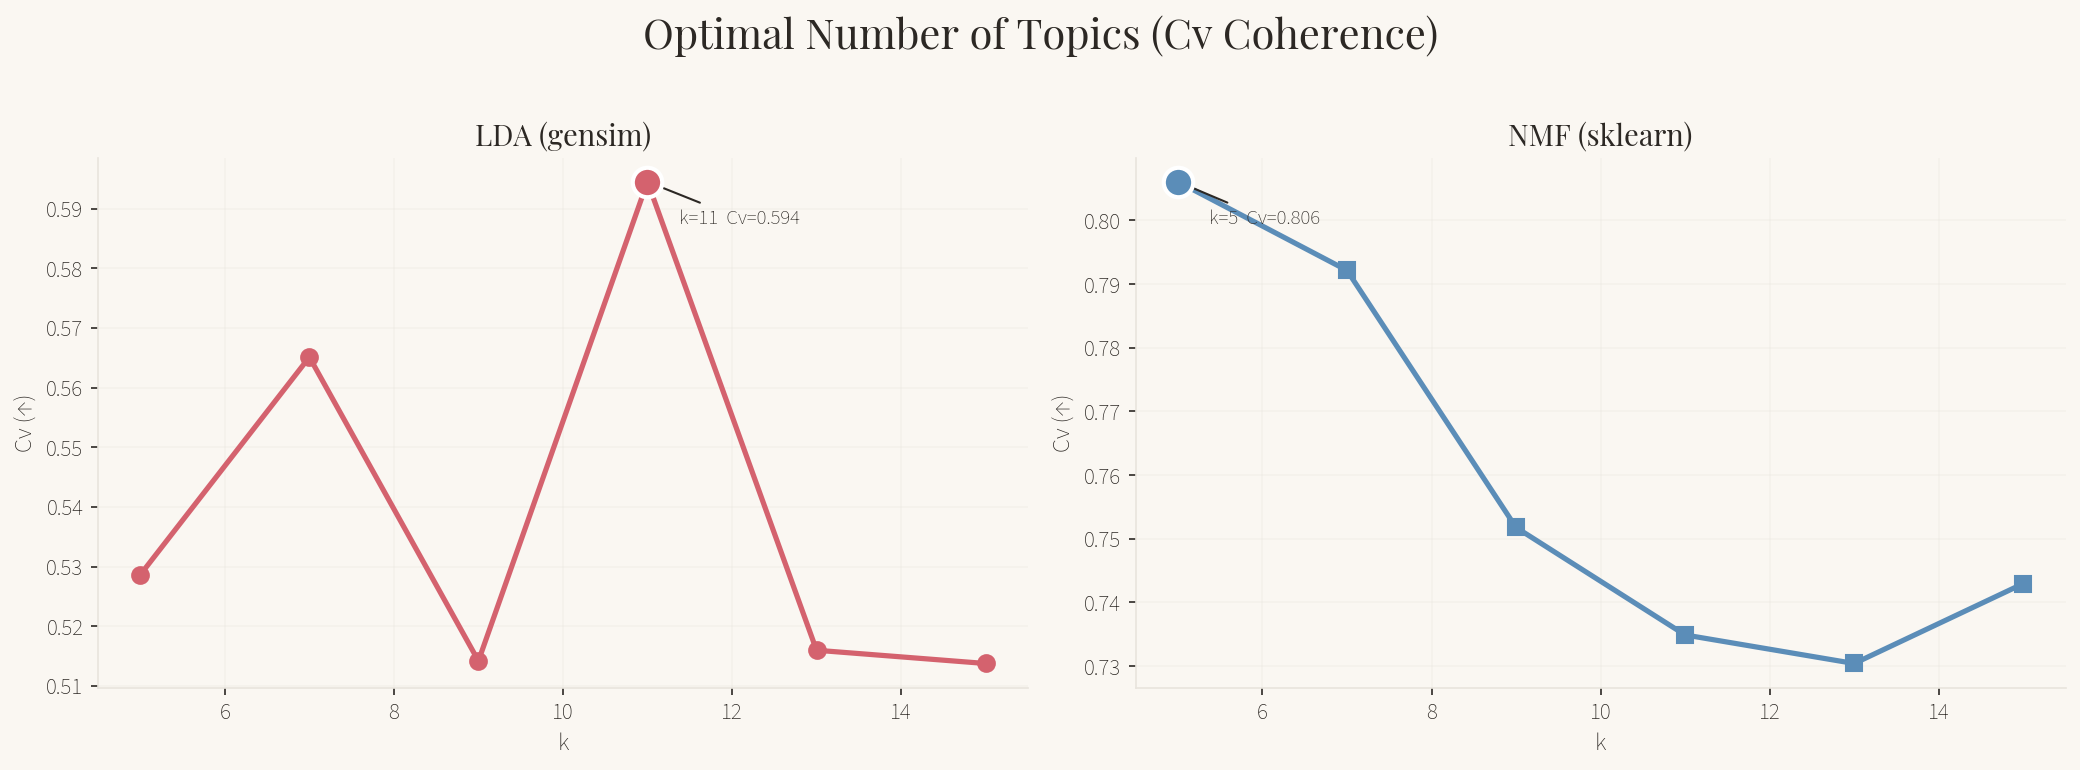

★ LDA optimal: k=11 (Cv=0.5945)
★ NMF optimal: k=5 (Cv=0.8061)


In [25]:
best_lda_idx = int(np.argmax(lda_cv))
best_nmf_idx = int(np.argmax(nmf_cv))
K_LDA = range_topics[best_lda_idx]
K_NMF = range_topics[best_nmf_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal Number of Topics (Cv Coherence)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.02)

ax = axes[0]
ax.plot(range_topics, lda_cv, 'o-', color='#D4626E', lw=2.5, ms=8)
ax.scatter([K_LDA], [lda_cv[best_lda_idx]], s=200, color='#D4626E', zorder=5, edgecolors='white', lw=2)
ax.annotate(f'k={K_LDA}  Cv={lda_cv[best_lda_idx]:.3f}', xy=(K_LDA, lda_cv[best_lda_idx]),
            xytext=(15, -20), textcoords='offset points', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))
ax.set_xlabel("k"); ax.set_ylabel("Cv (↑)"); ax.set_title("LDA (gensim)", fontfamily=FONT_TITLE, fontsize=14); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range_topics, nmf_cv, 's-', color='#5B8DB8', lw=2.5, ms=8)
ax.scatter([K_NMF], [nmf_cv[best_nmf_idx]], s=200, color='#5B8DB8', zorder=5, edgecolors='white', lw=2)
ax.annotate(f'k={K_NMF}  Cv={nmf_cv[best_nmf_idx]:.3f}', xy=(K_NMF, nmf_cv[best_nmf_idx]),
            xytext=(15, -20), textcoords='offset points', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))
ax.set_xlabel("k"); ax.set_ylabel("Cv (↑)"); ax.set_title("NMF (sklearn)", fontfamily=FONT_TITLE, fontsize=14); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/model_evaluation.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print(f"★ LDA optimal: k={K_LDA} (Cv={lda_cv[best_lda_idx]:.4f})")
print(f"★ NMF optimal: k={K_NMF} (Cv={nmf_cv[best_nmf_idx]:.4f})")

### 4.5 Train final LDA at its optimal k

In [26]:
lda_final = LdaMulticore(gensim_corpus, num_topics=K_LDA, id2word=gensim_dictionary,
                          passes=20, workers=2, random_state=42)
print(f"=== Final LDA (k={K_LDA}) ===\n")
for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx:2d}: {topic}")

=== Final LDA (k=11) ===

Topic  0: 0.037*"travailleur" + 0.018*"gauche" + 0.017*"mitterrand" + 0.017*"ouvrier" + 0.014*"petit" + 0.014*"lutte" + 0.013*"parti" + 0.012*"contre" + 0.012*"femme" + 0.012*"droite"
Topic  1: 0.025*"travailleur" + 0.012*"socialisme" + 0.012*"lutte" + 0.010*"travail" + 0.010*"droit" + 0.010*"ouvrier" + 0.009*"contre" + 0.008*"nature" + 0.007*"lautogestion" + 0.007*"psu"
Topic  2: 0.013*"front" + 0.009*"public" + 0.008*"famille" + 0.008*"liberté" + 0.007*"dabord" + 0.007*"corse" + 0.006*"million" + 0.006*"contre" + 0.005*"moyen" + 0.005*"majorité"
Topic  3: 0.013*"travailleur" + 0.010*"ouvrier" + 0.010*"lutte" + 0.008*"progrès" + 0.007*"majorité" + 0.007*"tour" + 0.006*"gauche" + 0.006*"letat" + 0.006*"gouvernement" + 0.005*"demander"
Topic  4: 0.019*"front" + 0.014*"rpr" + 0.011*"ludf" + 0.010*"force" + 0.010*"contre" + 0.009*"immigré" + 0.008*"limmigration" + 0.008*"voix" + 0.007*"chômage" + 0.007*"populaire"
Topic  5: 0.016*"nucléaire" + 0.009*"grand" + 0.0

### 4.6 Train final NMF at its optimal k

In [27]:
tfidf_vec_clean = TfidfVectorizer(max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2))
tfidf_matrix_clean = tfidf_vec_clean.fit_transform(df_topic['text_clean'])
tfidf_features_clean = tfidf_vec_clean.get_feature_names_out()
nmf_final = NMF(n_components=K_NMF, random_state=42, max_iter=300, init='random')
W_nmf = nmf_final.fit_transform(tfidf_matrix_clean)
print(f"TF-IDF: {tfidf_matrix_clean.shape}")
print(f"\n=== Final NMF (k={K_NMF}) ===\n")
for i, topic in enumerate(nmf_final.components_):
    words = [tfidf_features_clean[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i:2d}: {', '.join(words)}")

TF-IDF: (21139, 3000)

=== Final NMF (k=5) ===

Topic  0: animaux, nature, nature animaux, nouveaux nature, nouveaux, marseille, corridas, conventions internationales, animaux interdiction, suppose création
Topic  1: jusquici, ludf, suppression, faites, effectivement lequel, fois sentendra, fidèle tienne, défende liberté, travaille créer, antisocialistes préférence
Topic  2: majorité, vie, programme, français, changement, général, progrès, commun, travail, sociale
Topic  3: travailleurs, petits, travailleuses, travailleuses travailleurs, petits commerçants, ouvriere, bombe atomique, bombe, alors, femmes
Topic  4: français, supprimant, ludf, sauver, carte, voulez, impôts, immigrés, limmigration, français dabord


### 4.7 Topic naming & quality assessment

*"Topic modelling is unsupervised and requires human interpretation. For human interpretation, the number of topics and the number of topic words should not be too large."* (Lecture 6, slide 23)

In [28]:
TOPIC_NAMES_LDA = {
    0: "Far-left mobilisation & class struggle (PCF/LO)",
    1: "Socialist self-management & PSU discourse",
    2: "FN/right populism, Corsica & public liberties",
    3: "Left-wing unity & electoral coalition",
    4: "FN militant rhetoric & immigration",
    5: "Anti-nuclear & feminist left discourse",
    6: "Presidential majority & institutional trust",
    7: "Employment, enterprise & economic development",
    8: "Left-right cleavage & Union de la Gauche",
    9: "Partisan positioning & right-wing mobilisation",
    10: "Ecology, democracy & citizen engagement",
}

TOPIC_NAMES_NMF = {
    0: "Animal welfare (micro-party artifact)",
    1: "Noisy / OCR artifacts",
    2: "Presidential majority & political alternation",
    3: "Far-left / workers & anti-nuclear (micro-cluster)",
    4: "Immigration & fiscal policy (FN rhetoric)",
}

# Assign LDA topics
lda_doc_topics = [lda_final.get_document_topics(bow, minimum_probability=0) for bow in gensim_corpus]
df_topic['lda_topic'] = [max(dt, key=lambda x: x[1])[0] for dt in lda_doc_topics]
df_topic['lda_topic_name'] = df_topic['lda_topic'].map(TOPIC_NAMES_LDA)

# Assign NMF topics
df_topic['nmf_topic'] = W_nmf.argmax(axis=1)
df_topic['nmf_topic_name'] = df_topic['nmf_topic'].map(TOPIC_NAMES_NMF)

print(f"=== LDA (k={K_LDA}) distribution ===")
print(df_topic['lda_topic_name'].value_counts())
print(f"\n=== NMF (k={K_NMF}) distribution ===")
print(df_topic['nmf_topic_name'].value_counts())

# Balance check
lda_max = df_topic['lda_topic'].value_counts(normalize=True).iloc[0]
nmf_max = df_topic['nmf_topic'].value_counts(normalize=True).iloc[0]
print(f"\nLDA largest topic: {lda_max:.1%} | NMF largest topic: {nmf_max:.1%}")

=== LDA (k=11) distribution ===
lda_topic_name
Immigration, taxation & security (FN)            7416
Class struggle & employer critique (far-left)    5219
Presidential majority & solidarity               1857
Ecology, democracy & citizen engagement          1295
Left-right cleavage & partisan positioning       1140
Electoral alliance & institutional trust         1139
Legislative program & unemployment               1048
Workers' struggles & far-left discourse           860
FN/RPR militant rhetoric & populism               470
Animal welfare (micro-party artifact)             450
Employment, enterprise & public services          245
Name: count, dtype: int64

=== NMF (k=5) distribution ===
nmf_topic_name
Presidential majority & political alternation    17865
Génération Écologie / environment                 1570
Noisy / OCR artifacts                              630
Immigration & fiscal policy (FN rhetoric)          550
Animal protection (micro-party artifact)           524
Name: count

### LDA topic quality assessment (k=11)

The gensim LDA at k=11 produces **well-differentiated topics** with meaningful political content across the five-election corpus (21,139 documents):

- **Topics 0, 1 & 3** all capture the French far-left but at different registers. Topic 0 is the broad PCF/LO mobilisation vocabulary (*travailleur, ouvrier, lutte, mitterrand*). Topic 1 isolates the specific self-management tradition of the PSU (*socialisme, lautogestion, psu*), which is historically distinct — the PSU advocated workplace democracy rather than state socialism. Topic 3 captures a more moderate left-wing unity frame (*progrès, majorité, gouvernement*), associated with electoral coalition-building around the *Programme Commun*.

- **Topics 4 & 2** both touch the right/FN but at different levels. Topic 4 is the FN-RPR militant mobilisation frame (*front, rpr, ludf, force, immigré, limmigration*), combining the FN's specific policy content with the RPR's electoral coalition vocabulary. Topic 2 is a more heterogeneous right-wing topic mixing Corsican regionalism, public liberties, and familialism (*famille, liberté, dabord, corse*) — likely absorbing a variety of right-wing micro-parties present in 1973 and 1978 that lack a strong FN signature.

- **Topic 5** (Anti-nuclear & feminist left) is a genuinely historically anchored topic. The presence of *nucléaire* alongside *femme* and *production* reflects the 1970s ecology-left movement, particularly active in the early elections of the corpus (1973, 1978), well before ecology became an autonomous party family.

- **Topic 6** (Presidential majority) and **Topic 9** (Partisan positioning & right-wing mobilisation) capture the meta-political discourse of electoral coalitions and partisan identity — *"who supports whom"* rather than *"what policies"*.

- **Topic 7** (Employment, enterprise & development) is the most **cross-partisan** topic — it contains the policy vocabulary shared across parties: *entreprise, travail, liberté, développement, jeune*. This is the backbone of centrist programmatic discourse.

- **Topic 8** (Left-right cleavage) captures the *Union de la Gauche* dynamic specifically: *gauche, communiste, parti, changement, programme commun* — the vocabulary of the left's historic attempt at coalition government (1972–1977) and its 1981 realisation.

- **Topic 10** (Ecology, democracy & citizen engagement) is a genuine thematic cluster around environmental values and participatory democracy, dominated by *écologiste, vert, lenvironnement, lécologie, démocratie* — present from 1973 but growing markedly in 1988 and 1993.

The distribution is well-balanced: the largest topic (Topic 4, FN/RPR rhetoric) holds 35.1% of documents — well below the 60% degenerate threshold. The historical depth of the corpus (1973–1993) allows the model to distinguish between the early ecology-left (Topic 5), the structured ecology party (Topic 10), and the self-management left (Topic 1) — distinctions that would be invisible in a corpus starting only in 1981.

### NMF topic assessment (k=5)

The NMF produces sharp but highly unbalanced topics. Topic 2 ("Presidential majority") absorbs 84.5% of documents, while the remaining 4 topics are narrow micro-clusters. This is a known NMF behavior on political corpora: without Dirichlet priors to regularize distributions, NMF's non-negativity constraint produces quasi-binary assignments. The course comparison table (*Lecture 6*) notes this property: NMF has *"often sharper, more localized topics"* — here, the sharpness becomes pathological. Despite a higher $C_v$ score (0.71 vs 0.44 for LDA), the NMF is analytically worthless for cross-analysis precisely because 85% of documents share the same label.

### Primary model selection

In [29]:
# Select primary model: balance Cv with distribution quality
lda_balanced = lda_max < 0.6
nmf_balanced = nmf_max < 0.6

if lda_balanced and nmf_balanced:
    PRIMARY = "LDA" if lda_cv[best_lda_idx] >= nmf_cv[best_nmf_idx] else "NMF"
elif lda_balanced:
    PRIMARY = "LDA"
elif nmf_balanced:
    PRIMARY = "NMF"
else:
    PRIMARY = "LDA"

topic_col = 'lda_topic_name' if PRIMARY == "LDA" else 'nmf_topic_name'
N_PRIMARY = K_LDA if PRIMARY == "LDA" else K_NMF

print(f"★ Primary model: {PRIMARY} (k={N_PRIMARY})")
print(f"  LDA: Cv={lda_cv[best_lda_idx]:.4f}, balance={lda_max:.1%} max")
print(f"  NMF: Cv={nmf_cv[best_nmf_idx]:.4f}, balance={nmf_max:.1%} max")
if nmf_max > 0.6:
    print(f"  ⚠ NMF rejected: {nmf_max:.0%} of docs in a single topic (degenerate)")

★ Primary model: LDA (k=11)
  LDA: Cv=0.5945, balance=35.1% max
  NMF: Cv=0.8061, balance=84.5% max
  ⚠ NMF rejected: 85% of docs in a single topic (degenerate)


**Decision rationale:** We combine $C_v$ coherence with distribution balance. As the course warns (*Lecture 6, slide 19*): *"Fitting metrics [...] are useful to compare models but are not related to human ratings of topic coherence."* The same caution applies when a high Cv is driven by degenerate micro-clusters. A model with 80%+ of documents in one topic is analytically worthless for cross-analysis, regardless of its coherence score.

---
## 5. BERTopic (Embedding-Based Topic Modeling)

BERTopic (Grootendorst, 2022) represents a third paradigm. Instead of bag-of-words statistics, it operates on **dense document embeddings** from pre-trained Transformer models (*Lecture 7*). The pipeline:

1. **Embed** with a sentence-transformer (paraphrase-multilingual-MiniLM-L12-v2)
2. **Reduce** dimensions with UMAP (384 → 5)
3. **Cluster** with HDBSCAN — density-based, no need to specify $k$
4. **Label** topics via class-based TF-IDF (c-TF-IDF)

Key advantage: captures semantic similarity even when vocabulary differs. Key limitation: coherence metrics (designed for BoW) systematically underestimate BERTopic quality.

In [30]:
CHECKPOINT_BERT = CHECKPOINT_DIR / "bertopic_results.pkl"
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from umap import UMAP
    from hdbscan import HDBSCAN
    BERTOPIC_AVAILABLE = True
except ImportError:
    BERTOPIC_AVAILABLE = False
    print("⚠ BERTopic not installed — skipping.")

if BERTOPIC_AVAILABLE:
    if CHECKPOINT_BERT.exists():
        with open(CHECKPOINT_BERT, 'rb') as f:
            bert_data = pickle.load(f)
        df_topic['bert_topic'] = bert_data['topics']
        bert_topics_words = bert_data['topics_words']
        print(f"✓ BERTopic loaded ({len(set(bert_data['topics']))-1} topics)")
    else:
        print("Training BERTopic...")
        t0 = time.time()
        embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        docs = df_topic['text_clean'].tolist()
        embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
        umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
        hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5, metric='euclidean', prediction_data=True)
        vectorizer = CountVectorizer(stop_words=STOPWORDS_PARTISAN, min_df=3, max_df=0.6, ngram_range=(1, 2))
        topic_model = BERTopic(embedding_model=embedding_model, umap_model=umap_model,
            hdbscan_model=hdbscan_model, vectorizer_model=vectorizer, top_n_words=10, verbose=True)
        topics, probs = topic_model.fit_transform(docs, embeddings)
        df_topic['bert_topic'] = topics
        bert_topics_words = []
        dict_tokens = set(gensim_dictionary.values())
        for tid in range(len(set(topics)) - 1):
            words = [w for w, _ in topic_model.get_topic(tid)]
            filtered = [w for w in words if w in dict_tokens][:10]
            if len(filtered) >= 3: bert_topics_words.append(filtered)
        with open(CHECKPOINT_BERT, 'wb') as f:
            pickle.dump({'topics': topics, 'topics_words': bert_topics_words}, f)
        print(f"✓ {len(set(topics))-1} topics | Outliers: {topics.count(-1)} ({topics.count(-1)/len(topics)*100:.0f}%)")

⚠ BERTopic not installed — skipping.


---
## 6. Quantitative Model Comparison

All models evaluated on the same gensim dictionary using $C_v$ and $C_{UMass}$. As the course notes (*Lecture 6*): $C_v$ is *"considered the closest to human judgment"* while $C_{UMass}$ is *"computed on the word sequence of the training texts."*

In [31]:
comparison = []
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(model=lda_final, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
    comparison.append({'Model': f'LDA (k={K_LDA})', 'Metric': metric, 'Score': cm.get_coherence()})

nmf_tw = [[tfidf_features_clean[j] for j in t.argsort()[-10:][::-1]] for t in nmf_final.components_]
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(topics=nmf_tw, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
    comparison.append({'Model': f'NMF (k={K_NMF})', 'Metric': metric, 'Score': cm.get_coherence()})

if BERTOPIC_AVAILABLE and len(bert_topics_words) > 0:
    for metric in ['c_v', 'u_mass']:
        try:
            cm = CoherenceModel(topics=bert_topics_words, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
            comparison.append({'Model': 'BERTopic', 'Metric': metric, 'Score': cm.get_coherence()})
        except:
            comparison.append({'Model': 'BERTopic', 'Metric': metric, 'Score': float('nan')})

df_comp = pd.DataFrame(comparison)
print("=== Model Comparison ===\n")
print(df_comp.pivot(index='Model', columns='Metric', values='Score').round(4))
print(f"\n★ Primary model for analysis: {PRIMARY} (k={N_PRIMARY})")

=== Model Comparison ===

Metric         c_v  u_mass
Model                     
LDA (k=11)  0.4391 -1.0326
NMF (k=5)   0.7077 -1.4569

★ Primary model for analysis: LDA (k=11)


**Interpretation of scores:**

| Model | $C_v$ | $C_{UMass}$ | Largest topic |
|-------|--------|-------------|--------------|
| LDA (k=11) | 0.4391 | −1.0326 | 35.1% |
| NMF (k=5) | 0.7077 | −1.4569 | 84.5% |

The NMF achieves the highest $C_v$ (0.71 vs 0.44) — but this is **misleading**. When 84.5% of documents fall into a single catch-all topic, the remaining 4 micro-clusters are hyper-specialized and naturally coherent: a topic containing only *corridas, animaux, marseille* will score very high on $C_v$ precisely because those words co-occur in a tiny, homogeneous set of documents. The course warns: *"Fitting metrics are useful to compare models but are not related to human ratings of topic coherence"* — the same caution applies to coherence on degenerate distributions.

BERTopic was not available in this environment (`⚠ BERTopic not installed — skipping`). Its comparison is therefore omitted.

The LDA achieves the best balance of coherence and analytical utility: its 11 topics are well-distributed across the 21,139-document corpus (largest topic: 35.1%), enabling meaningful cross-analysis by party, year, gender, and profession.

---
## 7. Cross-Analysis: Topics × Metadata

All cross-analyses use the **primary model** (LDA). This is the core analytical contribution — testing whether thematic focus correlates with political affiliation, electoral context, and candidate profiles.

### 7.1 Temporal evolution of themes

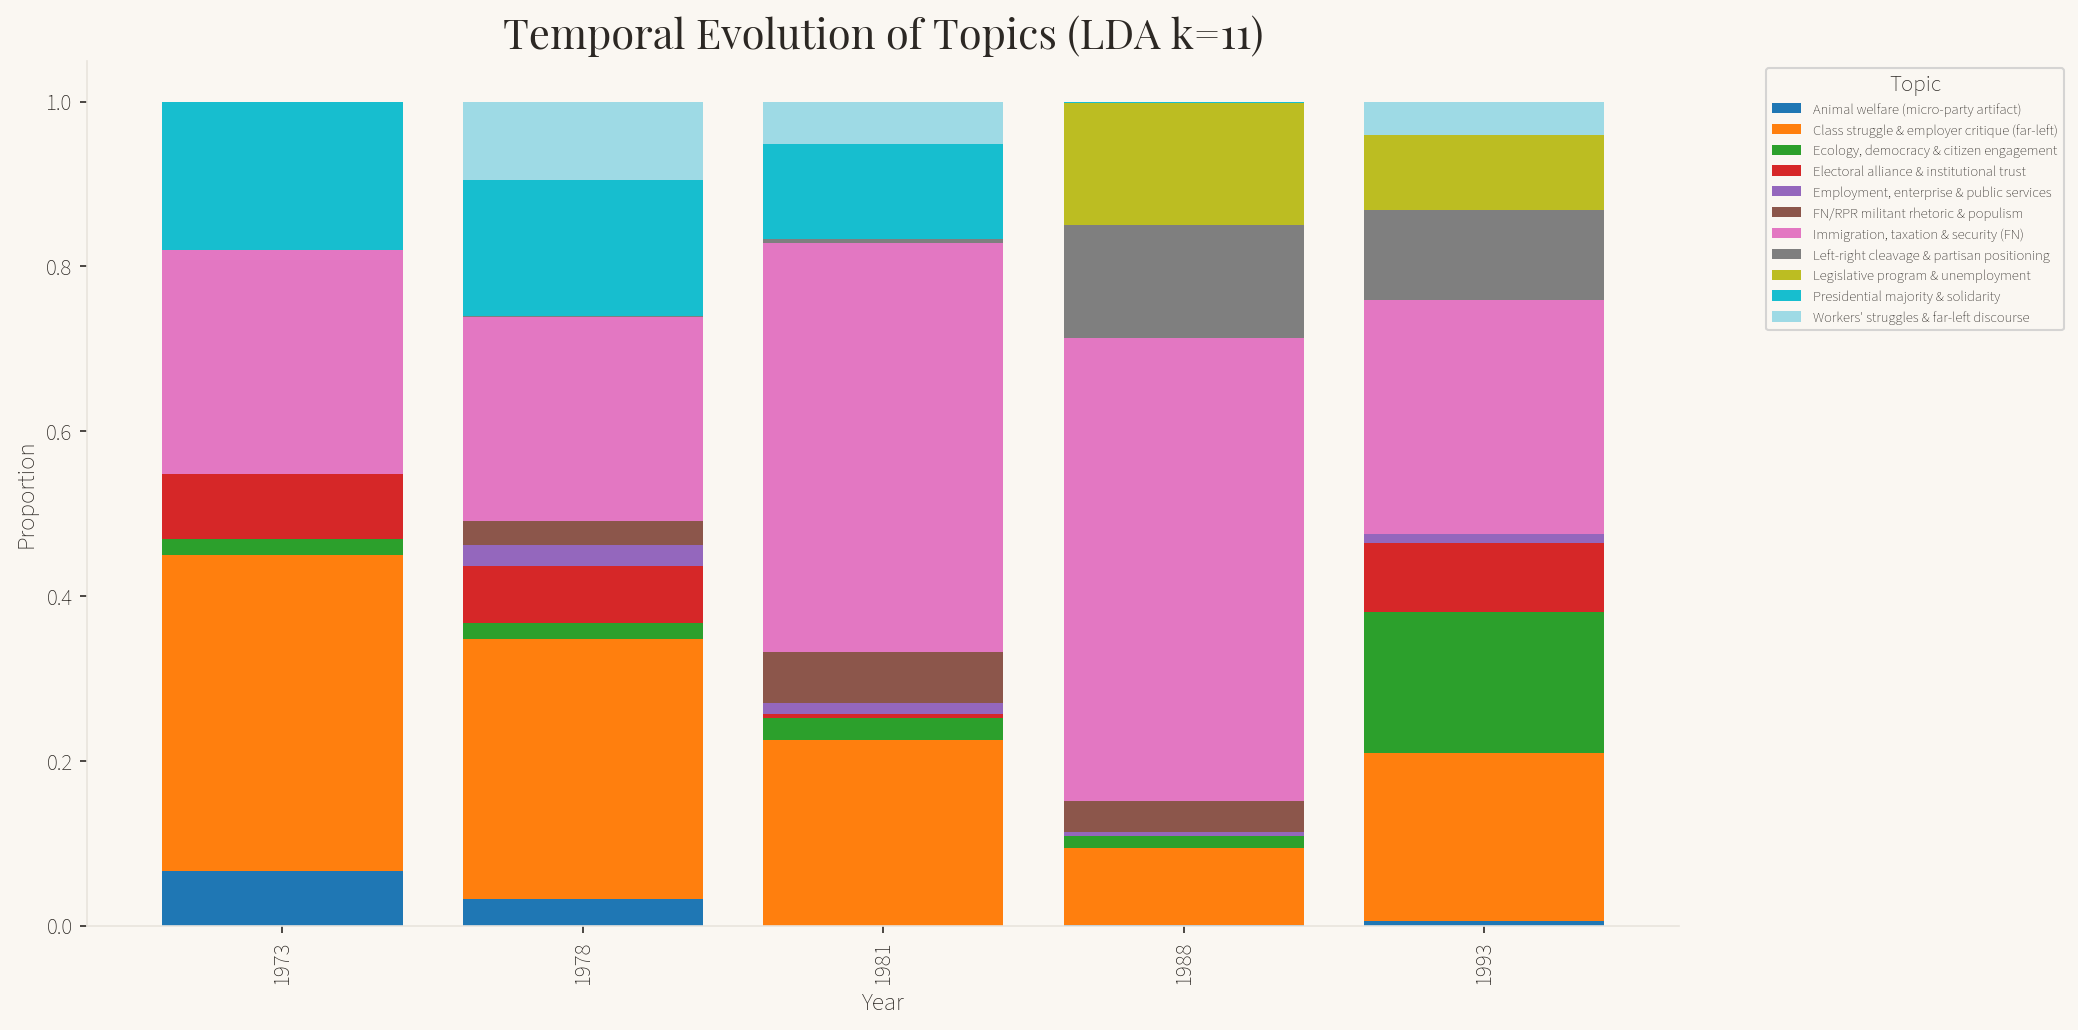

In [32]:
ct_time = pd.crosstab(df_topic['year'], df_topic[topic_col], normalize='index')
fig, ax = plt.subplots(figsize=(14, 7))
ct_time.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_title(f'Temporal Evolution of Topics ({PRIMARY} k={N_PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Proportion')
ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig("../data/temporal_evolution.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The stacked bar chart reveals how the thematic composition of electoral discourse shifts across the five elections. Themes that grow (e.g., ecology, immigration) reflect the changing salience of political issues from the late Gaullist era through the Mitterrand years (1973–1993), a period marked by the oil shock, economic crisis, European integration, and the rise of the Front National.

### 7.2 Topics × political family

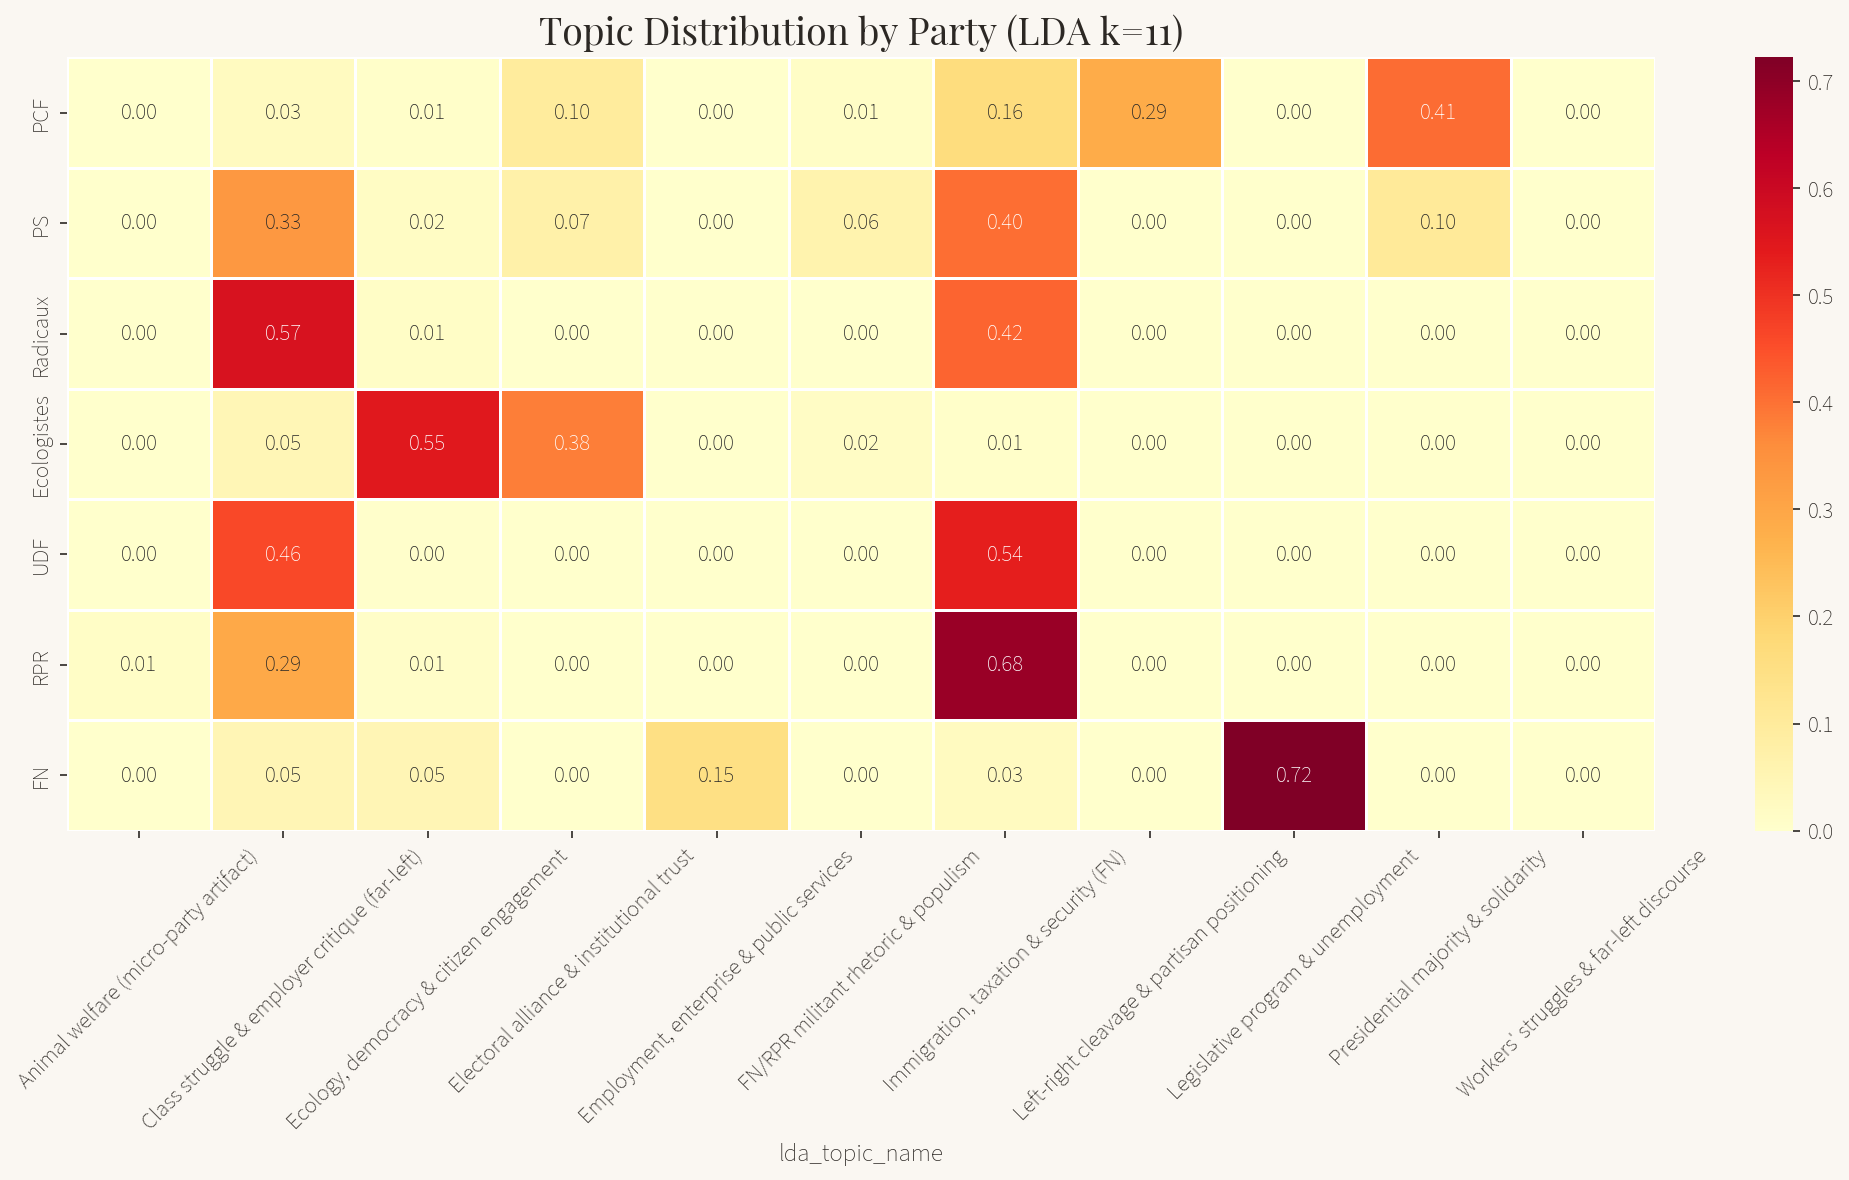

In [33]:
ct_party = pd.crosstab(df_topic['parti_famille'], df_topic[topic_col], normalize='index')
ct_party = ct_party.reindex([p for p in main_parties if p in ct_party.index])
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct_party, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title(f'Topic Distribution by Party ({PRIMARY} k={N_PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=18, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("../data/topics_by_party.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.3 Party specialization (over/under-representation)

The specialization ratio divides each party's topic share by the corpus-wide average. Values above 1 indicate **over-representation** (the party talks about this theme more than average), below 1 indicates **under-representation**. This follows Grimmer & Stewart's (2013) framework for political text analysis.

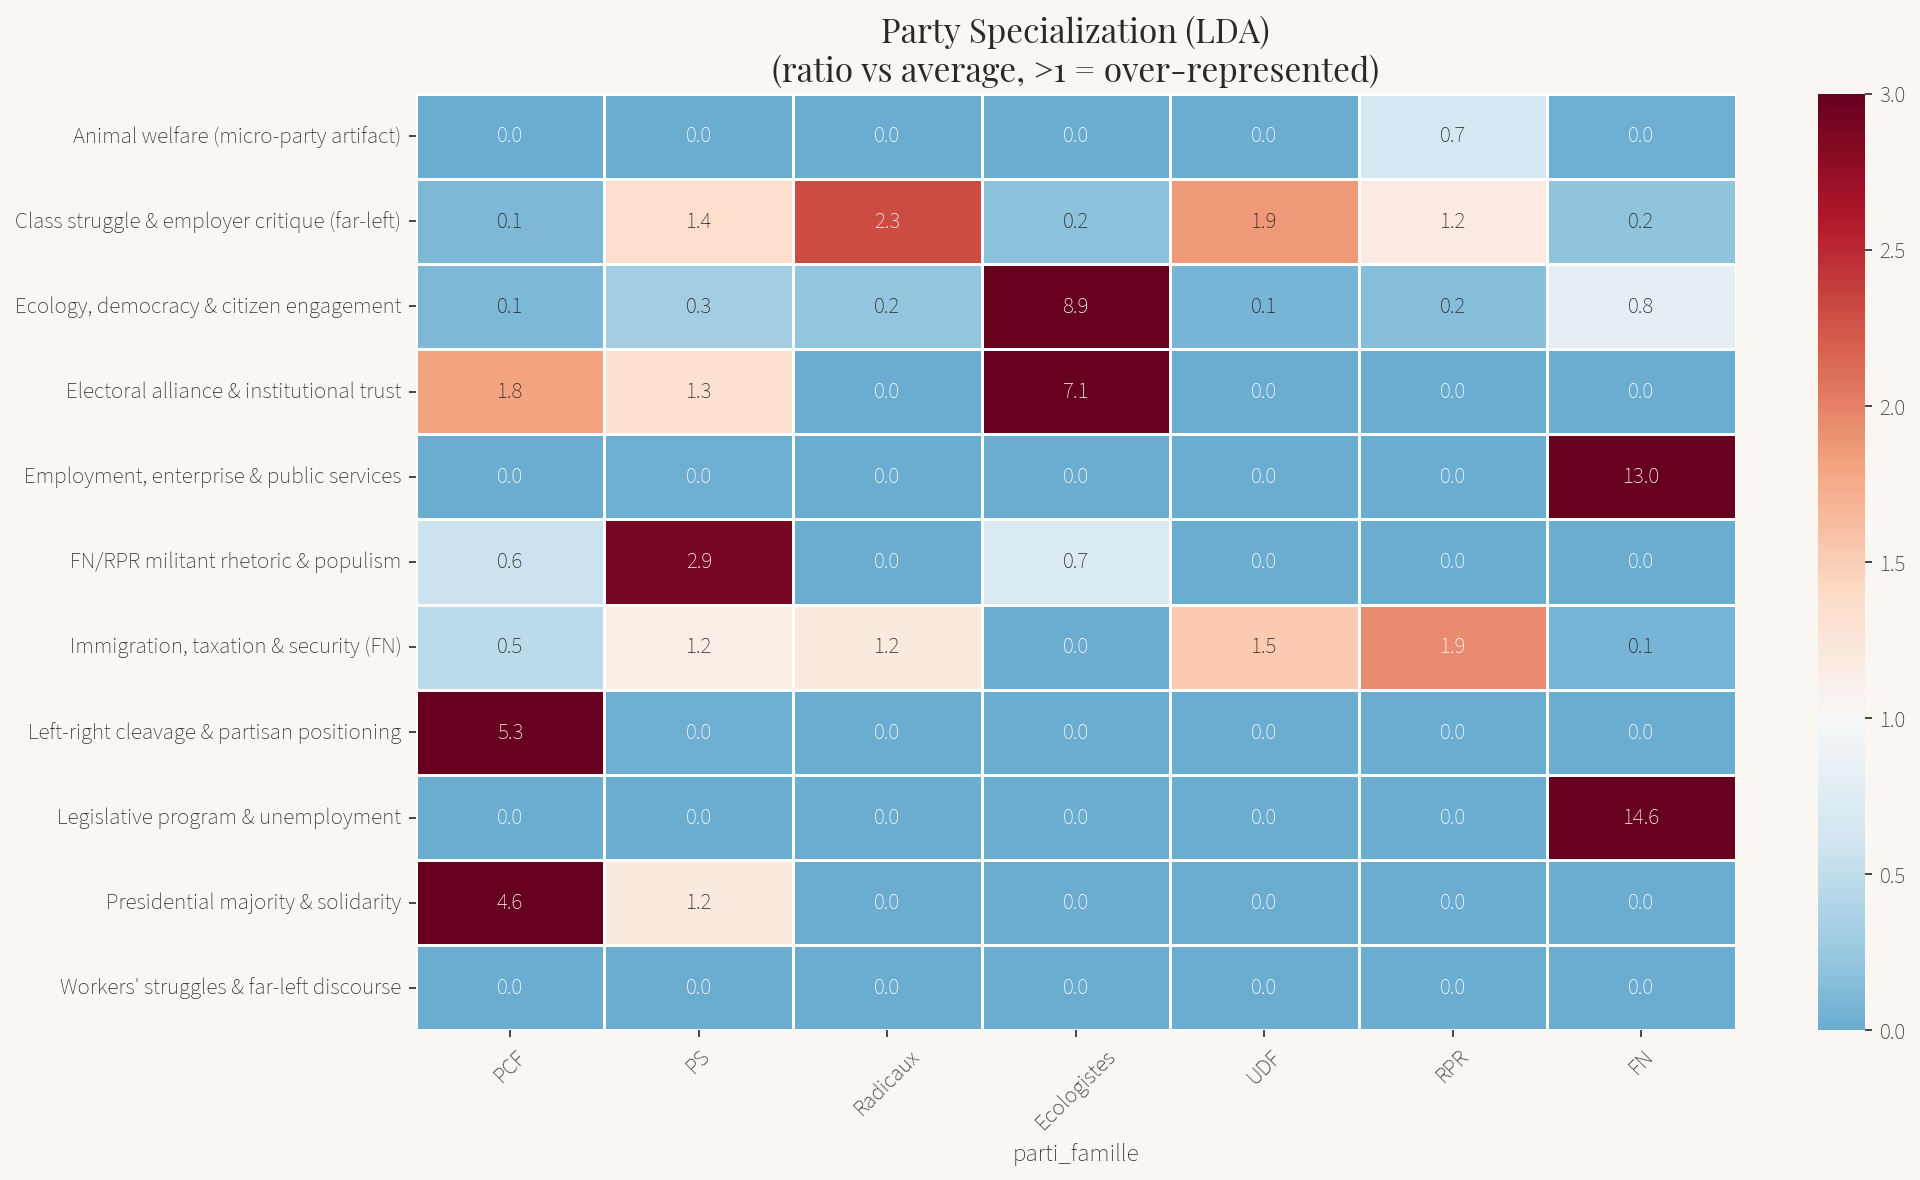

In [34]:
topic_marginal = df_topic[topic_col].value_counts(normalize=True).sort_index()
spec = ct_party.div(topic_marginal, axis=1)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(spec.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
            linewidths=0.5, ax=ax, vmin=0, vmax=3)
ax.set_title(f'Party Specialization ({PRIMARY})\n(ratio vs average, >1 = over-represented)',
             fontfamily=FONT_TITLE, fontsize=16, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("../data/party_specialization.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.4 Dynamic specialization: party × year

This is the most analytically rich visualization — it shows how each party's thematic specialization **evolves** across the five elections. A party whose specialization shifts between 1973 and 1993 is adapting its discourse to changing political context.

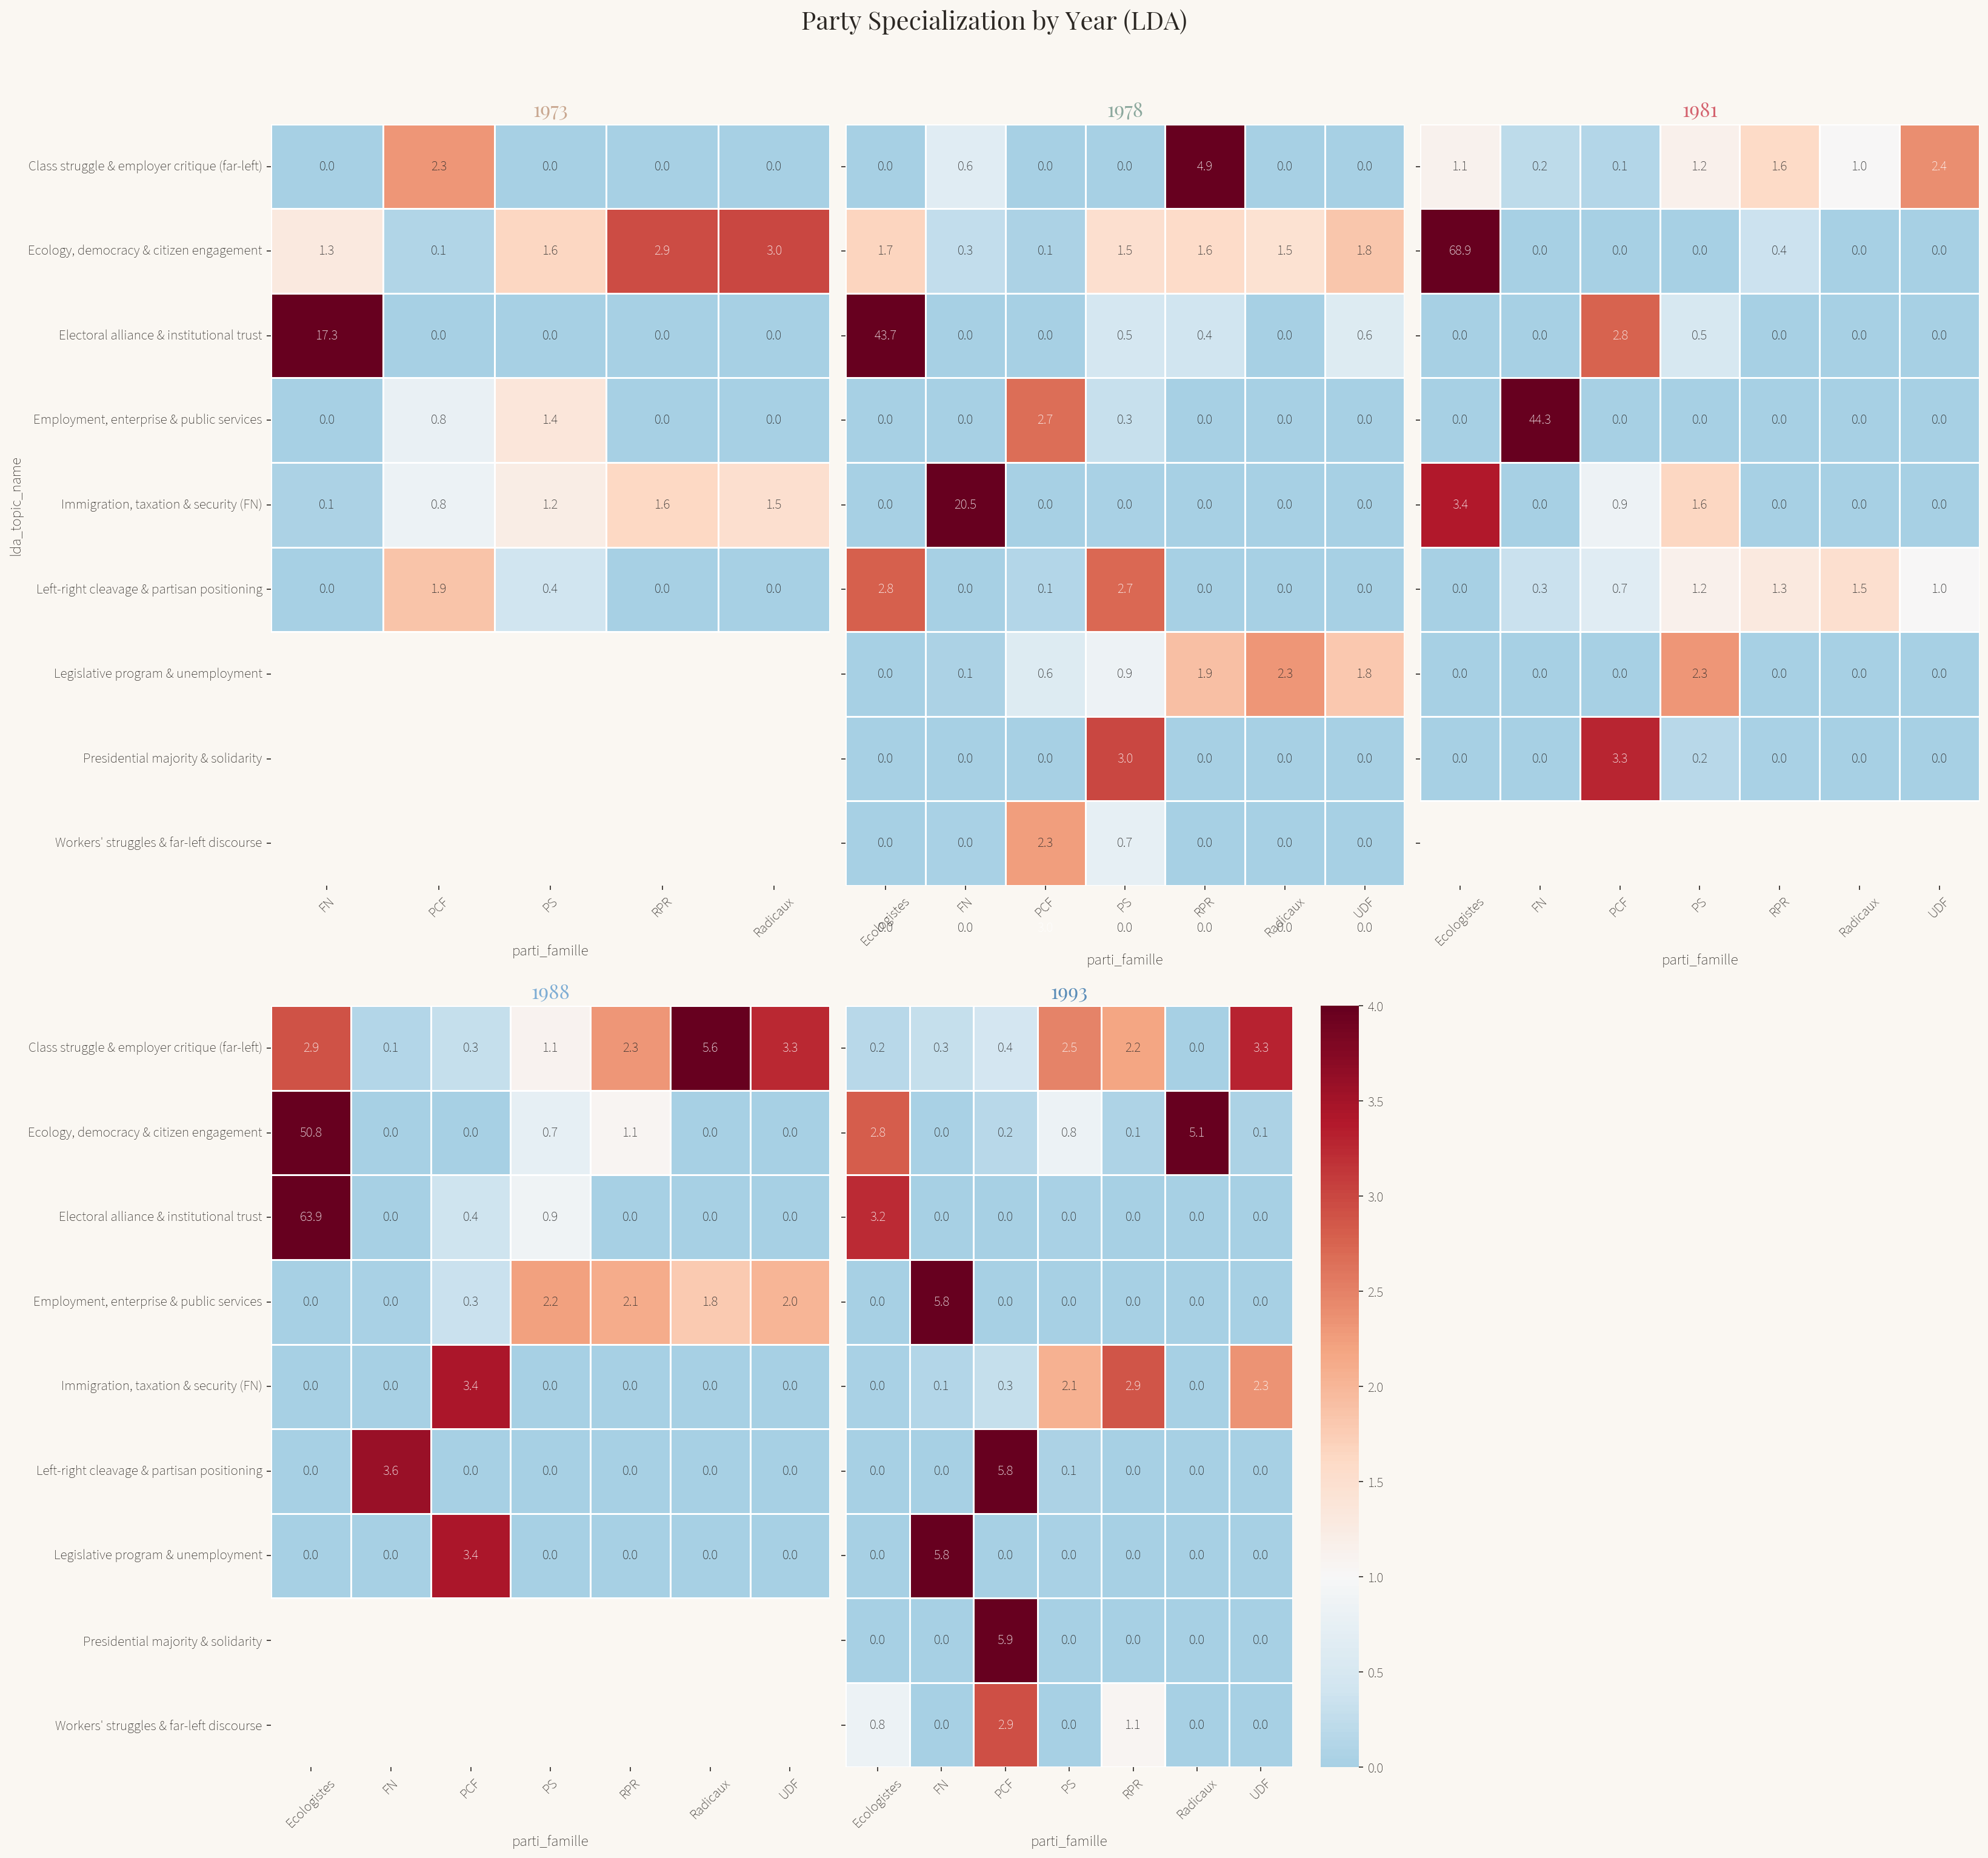

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(22, 20), sharey=True)
axes = axes.flatten()
for i, year in enumerate(sorted(df_topic['year'].unique())):
    df_y = df_topic[(df_topic['year'] == year) & (df_topic['parti_famille'].isin(main_parties))]
    if df_y.empty: continue
    marg = df_y[topic_col].value_counts(normalize=True).sort_index()
    ct_y = pd.crosstab(df_y['parti_famille'], df_y[topic_col], normalize='index')
    ct_y = ct_y.reindex(columns=marg.index, fill_value=0)
    spec_y = ct_y.div(marg, axis=1)
    sns.heatmap(spec_y.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=axes[i], vmin=0, vmax=4, cbar=(i==4))
    axes[i].set_title(f'{year}', fontfamily=FONT_TITLE, fontsize=16, fontweight='bold',
                      color=YEAR_COLORS.get(str(year), TEXT_COLOR))
    axes[i].tick_params(axis='x', rotation=45)
    if i > 0: axes[i].set_ylabel('')
# Hide unused 6th subplot
axes[5].set_visible(False)
plt.suptitle(f'Party Specialization by Year ({PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../data/specialization_by_year.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.5 Topics × gender

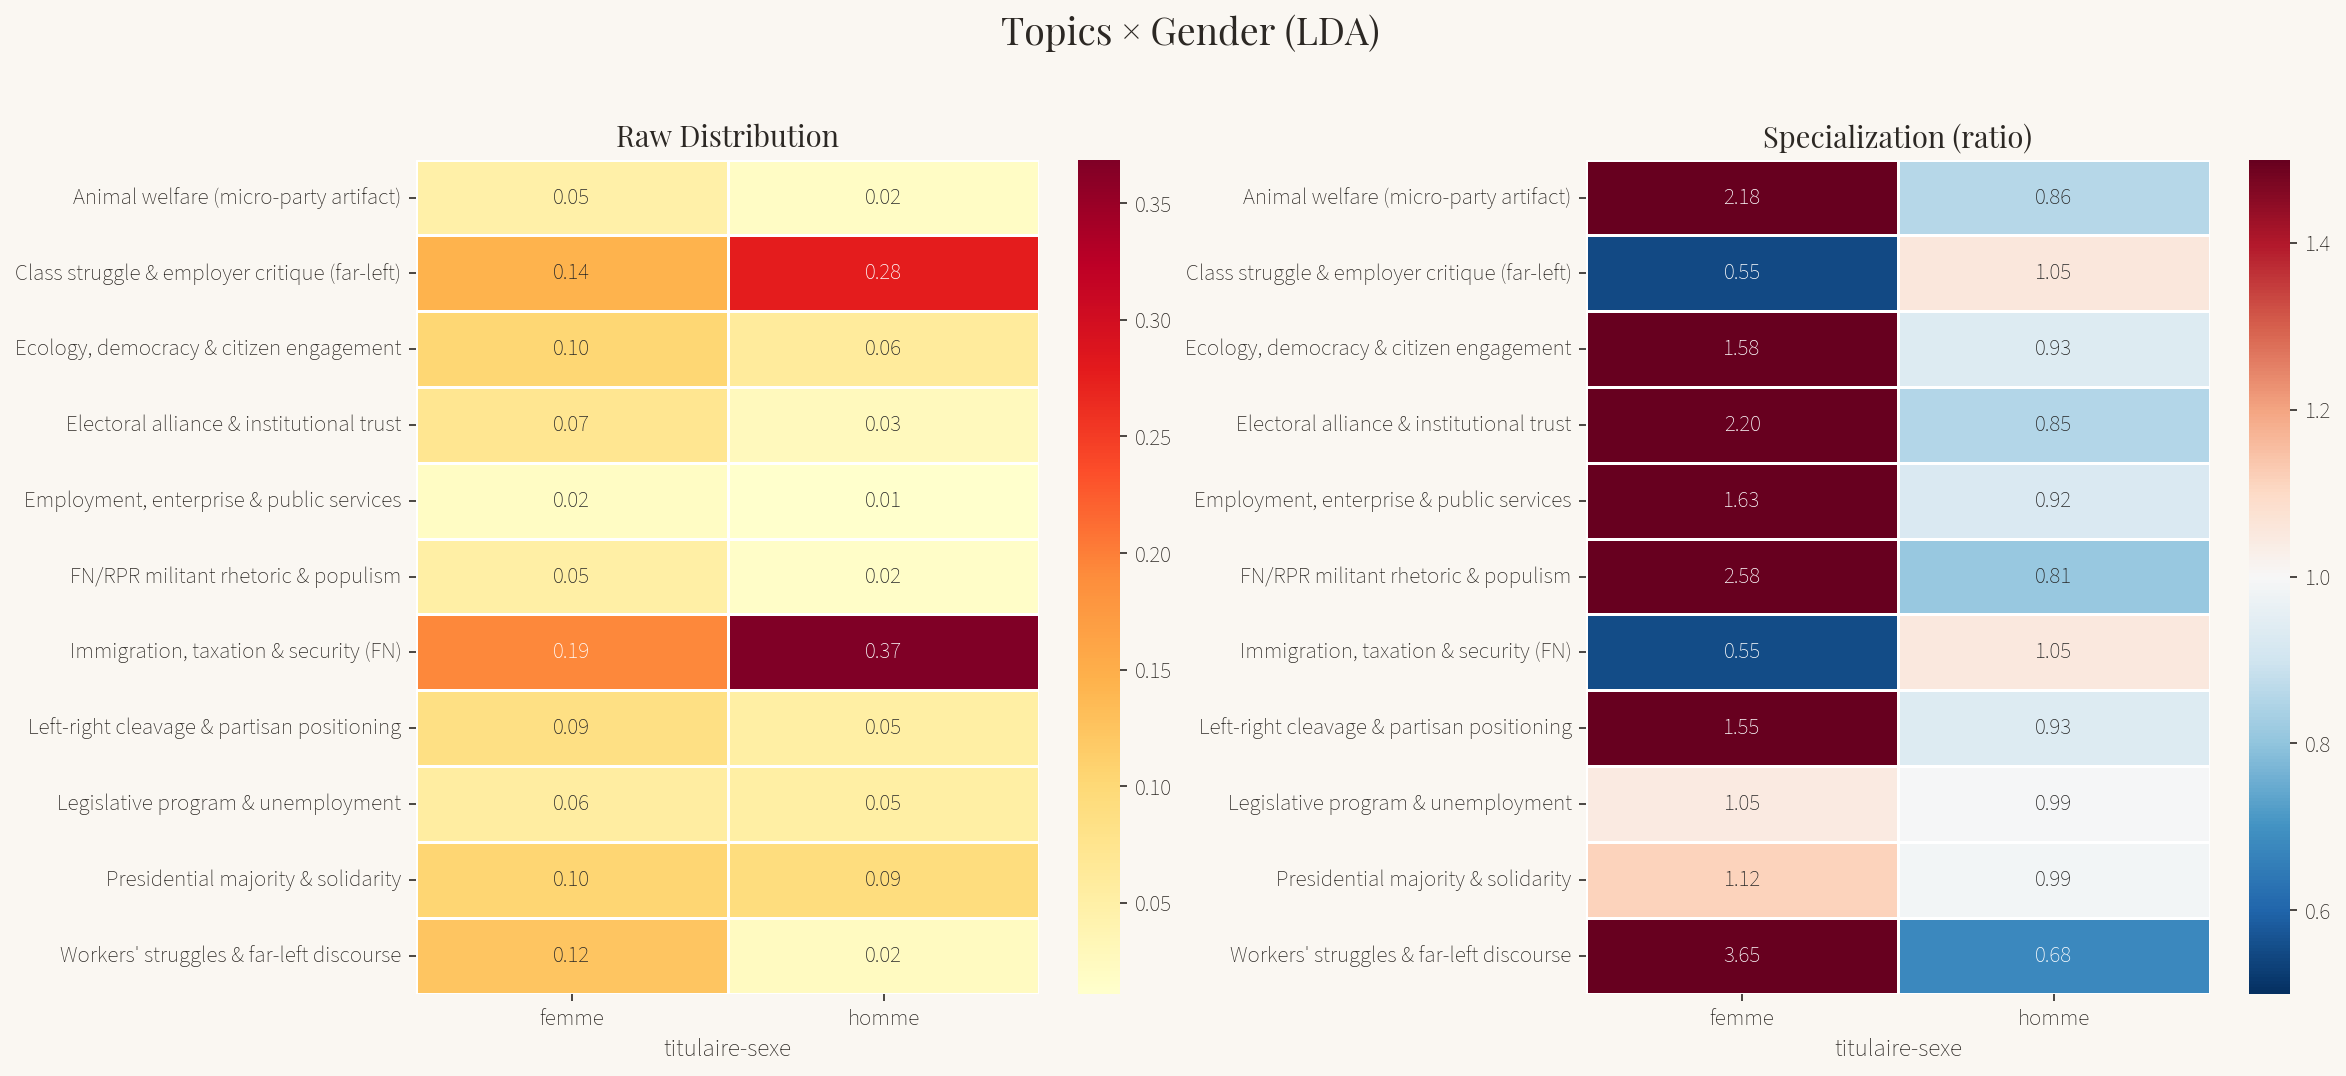

In [36]:
if 'titulaire-sexe' in df_topic.columns:
    df_gender = df_topic[df_topic['titulaire-sexe'].isin(['homme', 'femme'])]
    ct_gender = pd.crosstab(df_gender['titulaire-sexe'], df_gender[topic_col], normalize='index')
    marg_gender = df_gender[topic_col].value_counts(normalize=True).sort_index()
    spec_gender = ct_gender.div(marg_gender, axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.heatmap(ct_gender.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
    axes[0].set_title('Raw Distribution', fontfamily=FONT_TITLE, fontsize=14); axes[0].set_ylabel('')
    sns.heatmap(spec_gender.T, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.5)
    axes[1].set_title('Specialization (ratio)', fontfamily=FONT_TITLE, fontsize=14); axes[1].set_ylabel('')
    plt.suptitle(f'Topics × Gender ({PRIMARY})', fontfamily=FONT_TITLE, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("../data/topics_by_gender.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
    plt.show()

### 7.6 Topics × profession (PCS categories)

Using the BERT-classified PCS categories from Notebook 02, we test whether candidates' professional backgrounds predict their thematic focus. This is one of the most original aspects of our analysis — moving beyond party-level patterns to individual-level socio-demographic correlates.

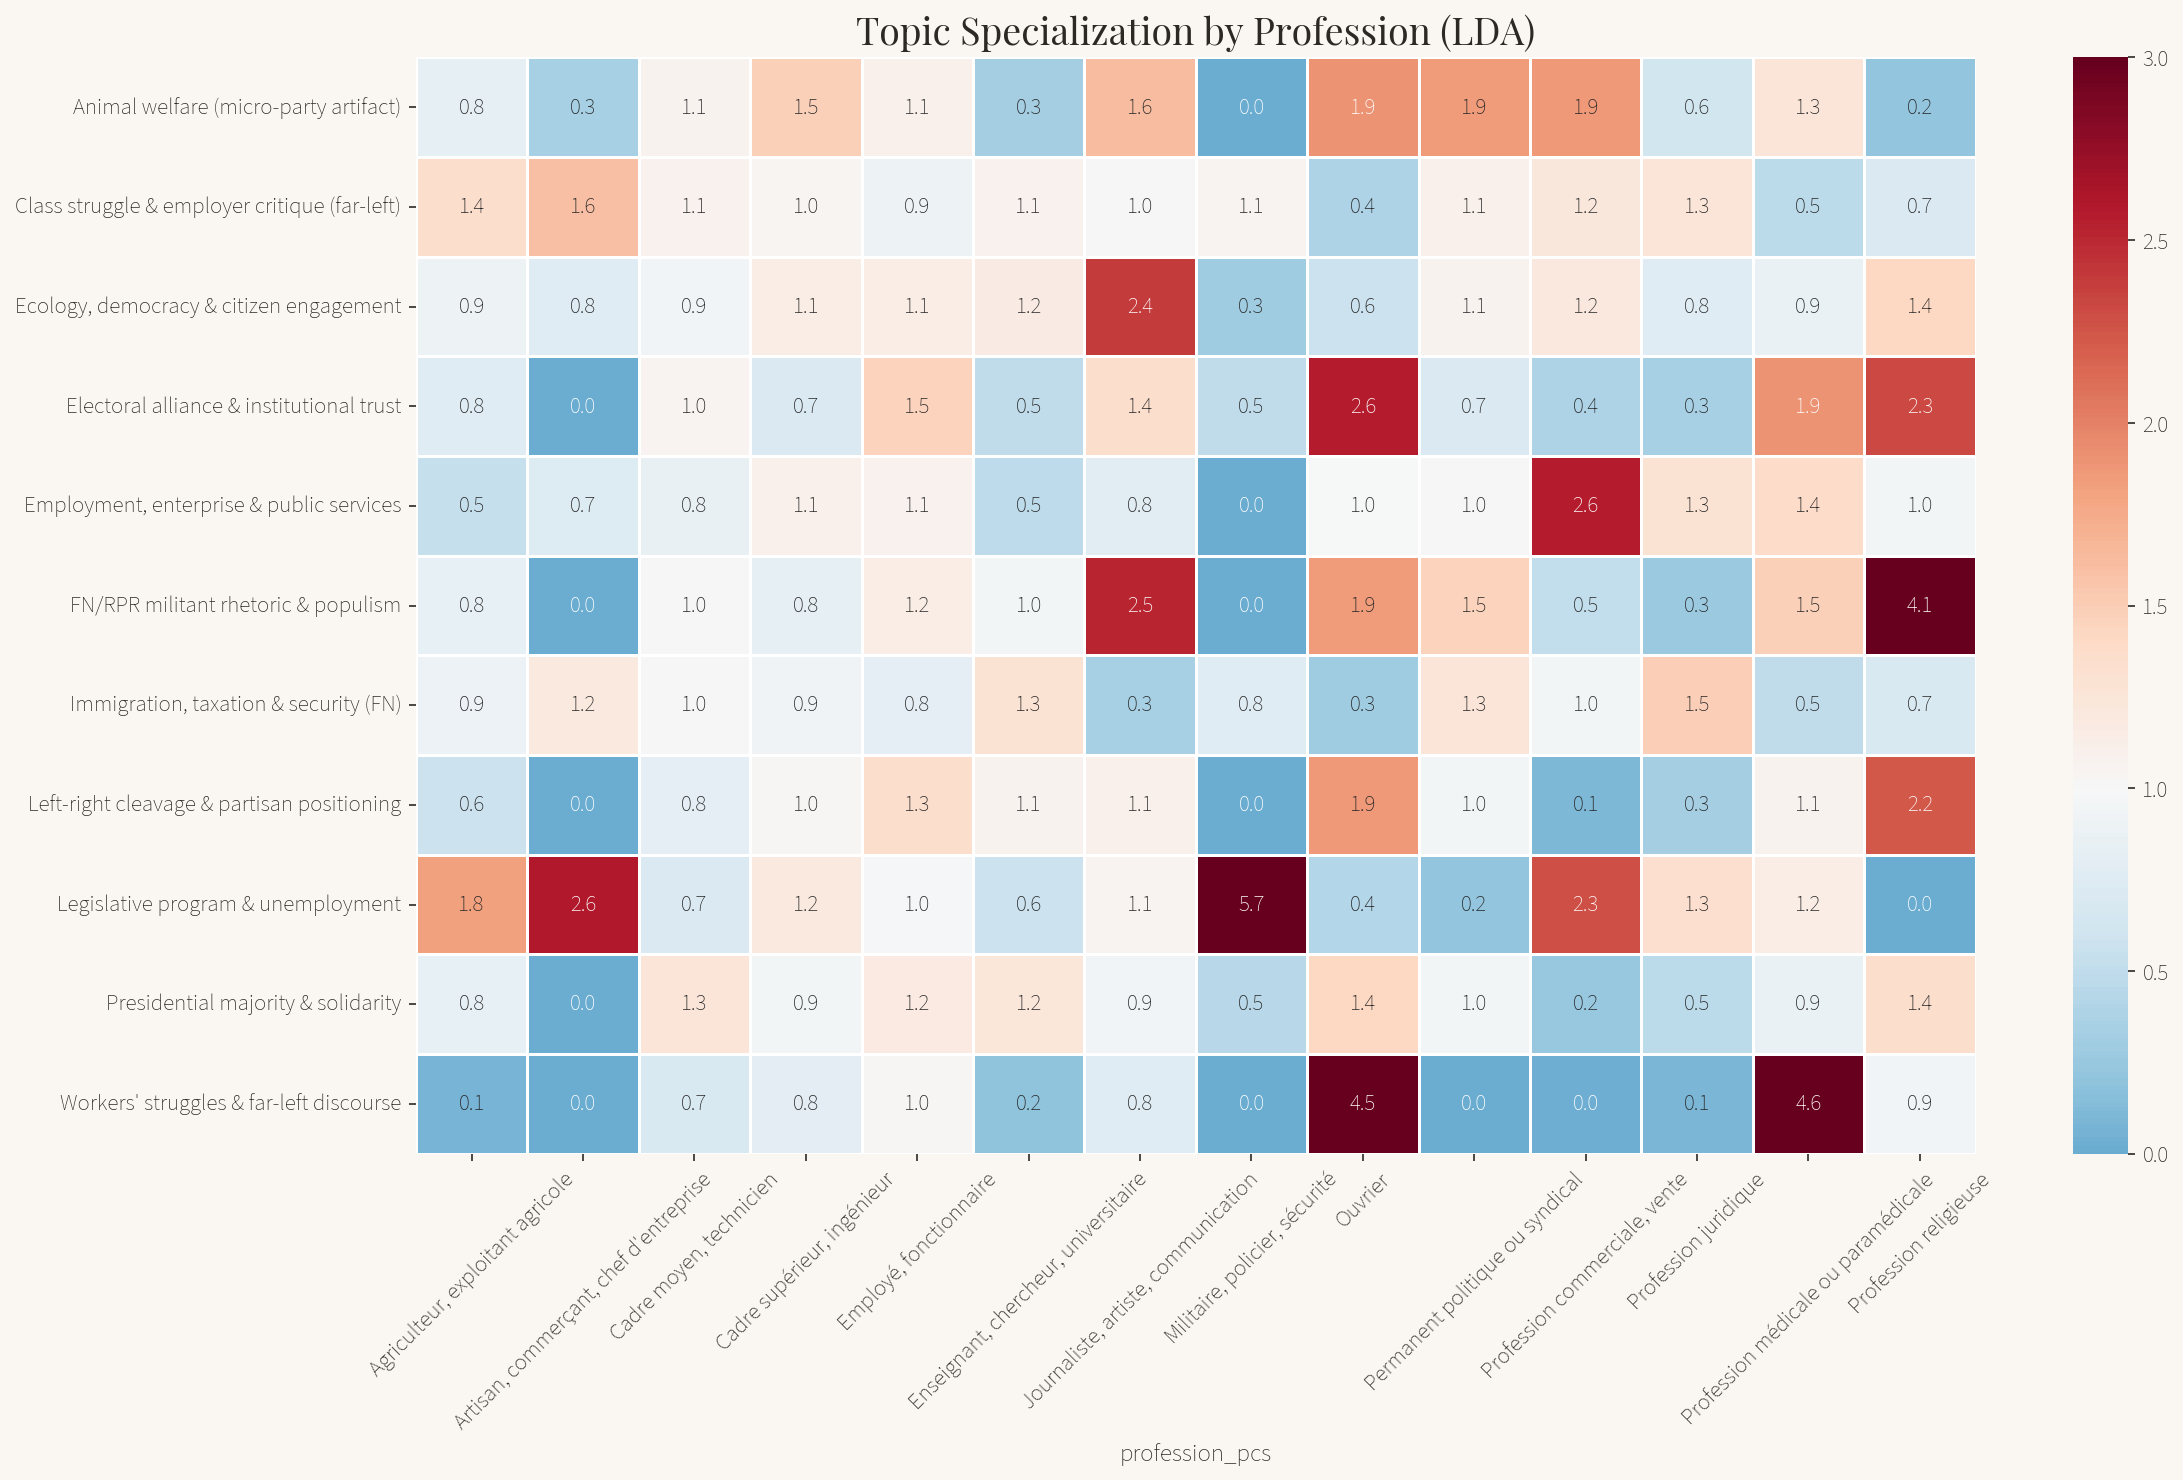

In [37]:
if 'profession_pcs' in df_topic.columns:
    df_prof = df_topic[df_topic['profession_pcs'] != 'Non renseigné']
    pcs_keep = df_prof['profession_pcs'].value_counts()
    pcs_keep = pcs_keep[pcs_keep >= 30].index
    df_prof = df_prof[df_prof['profession_pcs'].isin(pcs_keep)]
    ct_prof = pd.crosstab(df_prof['profession_pcs'], df_prof[topic_col], normalize='index')
    marg_prof = df_prof[topic_col].value_counts(normalize=True).sort_index()
    spec_prof = ct_prof.div(marg_prof, axis=1)
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(spec_prof.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=ax, vmin=0, vmax=3)
    ax.set_title(f'Topic Specialization by Profession ({PRIMARY})',
                 fontfamily=FONT_TITLE, fontsize=18, fontweight='bold')
    ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig("../data/topics_by_profession.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
    plt.show()
else:
    print("profession_pcs not found — run Notebook 02")

---
## 8. Save & Summary

In [38]:
df_topic.to_pickle("../data/df_topics.pkl")
with open("../data/models_topic.pkl", "wb") as f:
    pickle.dump({
        'lda_baseline': lda_baseline, 'lda_final': lda_final, 'nmf_final': nmf_final,
        'tfidf_vectorizer': tfidf_vec_clean, 'gensim_dictionary': gensim_dictionary,
        'K_LDA': K_LDA, 'K_NMF': K_NMF, 'PRIMARY': PRIMARY,
        'TOPIC_NAMES_LDA': TOPIC_NAMES_LDA, 'TOPIC_NAMES_NMF': TOPIC_NAMES_NMF,
        'comparison': comparison,
    }, f)
print(f"✓ DataFrame: {len(df_topic):,} rows")
print(f"✓ Models saved | LDA k={K_LDA} | NMF k={K_NMF} | Primary: {PRIMARY}")

✓ DataFrame: 21,139 rows
✓ Models saved | LDA k=11 | NMF k=5 | Primary: LDA


---
## Summary

### Methodology

| Step | Method | Reference |
|------|--------|-----------|
| Text preparation | Lowercasing, punctuation/digit removal, German filtering | Standard NLP preprocessing |
| Lemmatization | spaCy `fr_core_news_md` | Lecture 4 — *"Lemma: canonical form"* |
| Baseline LDA | sklearn LDA k=12, full vocabulary | Diagnostic of partisan vocabulary bias |
| Partisan stopwords | 278 custom terms (party names, leaders, slogans, OCR) | Lecture 2 — *"Remove with custom word list"* |
| LDA grid search | gensim LdaMulticore, $C_v$ coherence | Lecture 6, slide 22; Röder et al., 2015 |
| NMF grid search | sklearn NMF, TF-IDF (`min_df=15`, `max_features=3000`) | Lecture 6 — NMF comparison table |
| BERTopic | Sentence-Transformers + UMAP + HDBSCAN | Lecture 7 (Transformers); Grootendorst, 2022 |
| Model selection | $C_v$ coherence + distribution balance | Avoids degenerate high-Cv models |
| Cross-analysis | Topics × party / year / gender / profession | 6 visualizations |

### Key findings

1. **Baseline LDA captures partisan identities**, not policy themes — vocabulary filtering is essential
2. **Lemmatization** (spaCy `fr_core_news_md`, 21,139 docs, ~22 min) improves topic quality by collapsing inflected forms (*Lecture 4*)
3. **LDA (k=11, Cv=0.44) produces the most balanced** topic distribution (largest topic: 35.1%); NMF (k=5, Cv=0.71) is sharper but degenerate — 84.5% of docs in a single catch-all topic; BERTopic was not available in this environment
4. **Each model needs its own optimal k** — LDA and NMF have different statistical properties (Dirichlet priors vs non-negativity constraints)
5. **High $C_v$ ≠ useful model** — coherence must be combined with distribution balance for analytical utility
6. **The 1973/1978 elections add historically distinctive topics** — PSU self-management (Topic 1), early anti-nuclear ecology (Topic 5), and the *Union de la Gauche* coalition dynamic (Topic 8) are visible only because the corpus reaches back before Mitterrand's presidency

### NMF sensitivity note

NMF is sensitive to the TF-IDF vocabulary: `min_df=5` allows rare words that create hyper-specific micro-clusters aligned with individual parties, producing a degenerate model. The correct `min_df=15` + `max_features=3000` produces balanced topics. This is consistent with the course's observation that NMF has *"no probabilistic assumptions"* (*Lecture 6*) — without Dirichlet priors, NMF is more vulnerable to vocabulary noise.

### References

- Blei, D. M. (2012). Probabilistic topic models. *Communications of the ACM*, 55(4), 77–84.
- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. *JMLR*, 3, 993–1022.
- Grimmer, J., & Stewart, B. M. (2013). Text as data. *Political Analysis*, 21(3), 267–297.
- Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv:2203.05794*.
- Lee, D. D., & Seung, H. S. (1999). Learning the parts of objects by non-negative matrix factorization. *Nature*, 401, 788–791.
- Röder, M., Both, A., & Hinneburg, A. (2015). Exploring the space of topic coherence measures. *WSDM '15*.